# Regression on California House Pricing


In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load data
dataset = fetch_california_housing()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name='HouseValue')

In [5]:
# lets print X and y
print("X:\n", X.head())
print("y:\n", y.head())

X:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
y:
 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseValue, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Lets check the prediction on 1 datapoint: idx=2
# MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude Longitude
sample = [[7.2574, 52.0,  8.288136, 1.073446, 496.0, 2.802260, 37.85, -122.24 ],]

sample_df = pd.DataFrame(sample, columns=X.columns)

prediction = model.predict(sample_df)

print(prediction)

[3.67358]


In [10]:
# Lets evaluate on test

y_pred = model.predict(X_test)

In [15]:
# lets see the first 3 test data point, its actual value, predicted value
print(X_test[:3].values)
print(y_test[:3].values)
print(y_pred[:3])

[[ 1.68120000e+00  2.50000000e+01  4.19220056e+00  1.02228412e+00
   1.39200000e+03  3.87743733e+00  3.60600000e+01 -1.19010000e+02]
 [ 2.53130000e+00  3.00000000e+01  5.03938356e+00  1.19349315e+00
   1.56500000e+03  2.67979452e+00  3.51400000e+01 -1.19460000e+02]
 [ 3.48010000e+00  5.20000000e+01  3.97715472e+00  1.18587747e+00
   1.31000000e+03  1.36033229e+00  3.78000000e+01 -1.22440000e+02]]
[0.477   0.458   5.00001]
[0.71912284 1.76401657 2.70965883]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.5332001304956558
MSE: 0.555891598695244
RMSE: 0.7455813830127761
R2 Score: 0.5757877060324511


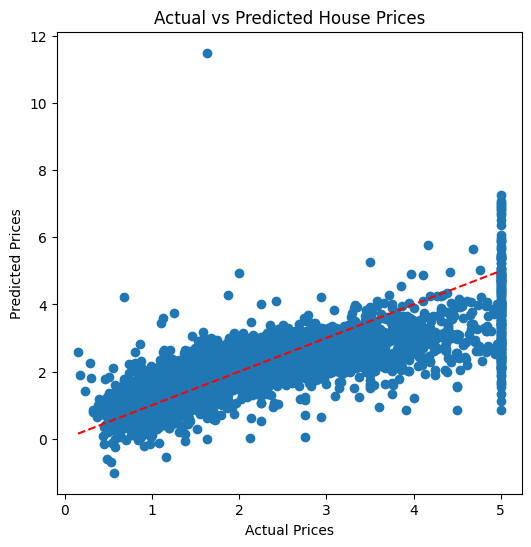

In [17]:
# Plot Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', )
plt.show()


In [18]:
importance = pd.Series(model.coef_, index=X.columns)
print(importance.sort_values(ascending=False))


AveBedrms     0.783145
MedInc        0.448675
HouseAge      0.009724
Population   -0.000002
AveOccup     -0.003526
AveRooms     -0.123323
Latitude     -0.419792
Longitude    -0.433708
dtype: float64
